In [1]:
import json
import pandas as pd
from pathlib import Path
from typing import List, Dict


def parse_result_filename(filename: str) -> Dict[str, str]:
    """
    Parse result filename to extract suffix and checkpoint.
    
    Expected formats:
    - eval_result_{suffix}_{checkpoint}.json
    - eval_result_{suffix}.json (when no checkpoint)
    - eval_result_{checkpoint}.json (when no suffix)
    - eval_result.json (when neither suffix nor checkpoint)
    
    Args:
        filename: The result filename to parse
        
    Returns:
        Dictionary with 'suffix' and 'checkpoint' keys
    """
    # Remove .json extension and eval_result_ prefix
    if not filename.endswith('.json'):
        raise ValueError(f"Invalid file extension: {filename}. Expected .json")
    
    name_without_ext = filename[:-5]  # Remove .json
    
    if not name_without_ext.startswith('eval_result'):
        raise ValueError(f"Invalid filename format: {filename}. Expected to start with 'eval_result'")
    
    # Remove eval_result prefix
    if name_without_ext == 'eval_result':
        # No suffix or checkpoint
        return {'suffix': '', 'checkpoint': ''}
    
    remainder = name_without_ext[12:]  # Remove 'eval_result_'
    
    if not remainder:
        return {'suffix': '', 'checkpoint': ''}
    
    # Split the remainder by underscores
    parts = remainder.split('_')
    
    if len(parts) == 1:
        # Could be either suffix or checkpoint
        # If it's all digits, assume it's a checkpoint
        if parts[0].isdigit():
            return {'suffix': '', 'checkpoint': parts[0]}
        else:
            return {'suffix': parts[0], 'checkpoint': ''}
    elif len(parts) == 2:
        # suffix_checkpoint
        return {'suffix': parts[0], 'checkpoint': parts[1]}
    else:
        # More than 2 parts - join all but last as suffix, last as checkpoint
        suffix = '_'.join(parts[:-1])
        checkpoint = parts[-1]
        return {'suffix': suffix, 'checkpoint': checkpoint}


def extract_success_rate(json_file_path: Path) -> float:
    """
    Extract success rate from evaluation JSON file.
    
    Args:
        json_file_path: Path to the JSON file
        
    Returns:
        Success rate as a percentage (0-100)
    """
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    
        return float(data['aggregated']['success_rate']), float(data['aggregated']['average_score'])




def extract_evaluation_results(eval_folders: List[str]) -> pd.DataFrame:
    """
    Extract evaluation results from a list of evaluation folders.
    
    Args:
        eval_folders: List of paths to evaluation folders (strings)
        
    Returns:
        DataFrame with columns: ['time', 'base_job', 'suffix', 'checkpoint', 'percent_successful']
    """
    all_results = []
    
    for folder_path_str in eval_folders:
        folder_path = Path(folder_path_str)
        
        if not folder_path.exists():
            print(f"Warning: Folder does not exist: {folder_path}")
            continue
        
        if not folder_path.is_dir():
            print(f"Warning: Path is not a directory: {folder_path}")
            continue
        
        # Extract base_job from folder name
        base_job = folder_path.name
        
        # Find all JSON files in the folder
        json_files = list(folder_path.glob('*.json'))
        
        if not json_files:
            print(f"Warning: No JSON files found in {folder_path}")
            continue
        
        print(f"Processing folder: {folder_path} ({len(json_files)} JSON files)")
        
        for json_file in json_files:
            try:
                file_info = parse_result_filename(json_file.name)
                success_rate, average_score = extract_success_rate(json_file)
                
                result = {
                    'time': '',  # No longer using time in folder structure
                    'base_job': base_job,
                    'suffix': file_info['suffix'],
                    'checkpoint': file_info['checkpoint'],
                    'percent_successful': success_rate,
                    'average_score': average_score,
                }
                
                all_results.append(result)
                
            except Exception as e:
                print(f"Error processing file {json_file}: {e}")
                continue
    
    if not all_results:
        print("Warning: No results extracted from any folders")
        return pd.DataFrame(columns=['time', 'base_job', 'suffix', 'checkpoint', 'percent_successful'])
    
    # Create DataFrame
    df = pd.DataFrame(all_results)
    
    # Sort by base_job, suffix, checkpoint
    df = df.sort_values(['base_job', 'suffix', 'checkpoint']).reset_index(drop=True)
    
    print(f"\nSuccessfully extracted {len(df)} results")
    print(f"Unique base jobs: {df['base_job'].nunique()}")
    print(f"Unique suffixes: {df['suffix'].nunique()}")
    print(f"Unique checkpoints: {df['checkpoint'].nunique()}")
    print(f"Average success rate: {df['percent_successful'].mean():.2f}%")
    
    return df


# Example usage:
# Example folder paths
folders = [
    "outputs/eval/concept_act_so100_30krun",
    "outputs/eval/act_normal_so100_30krun",
    "outputs/eval/concept_act_prediction_head_so100_30krun/",
]

df = extract_evaluation_results(folders)
print("\nFirst few rows:")
print(df.head())

Processing folder: outputs/eval/concept_act_so100_30krun (30 JSON files)
Processing folder: outputs/eval/act_normal_so100_30krun (30 JSON files)
Processing folder: outputs/eval/concept_act_prediction_head_so100_30krun (30 JSON files)

Successfully extracted 90 results
Unique base jobs: 3
Unique suffixes: 3
Unique checkpoints: 10
Average success rate: 48.89%

First few rows:
  time                 base_job   suffix checkpoint  percent_successful  \
0       act_normal_so100_30krun  seed100     003000                 0.0   
1       act_normal_so100_30krun  seed100     006000                40.0   
2       act_normal_so100_30krun  seed100     009000                40.0   
3       act_normal_so100_30krun  seed100     012000                20.0   
4       act_normal_so100_30krun  seed100     015000                80.0   

   average_score  
0            0.4  
1            1.3  
2            1.5  
3            0.6  
4            2.4  


In [2]:
df[['base_job','percent_successful', 'average_score']].groupby(['base_job']).mean()

,percent_successful,average_score
base_job,,
act_normal_so100_30krun,39.000000,1.350000
concept_act_prediction_head_so100_30krun,48.000000,1.460000
concept_act_so100_30krun,59.666667,1.886667


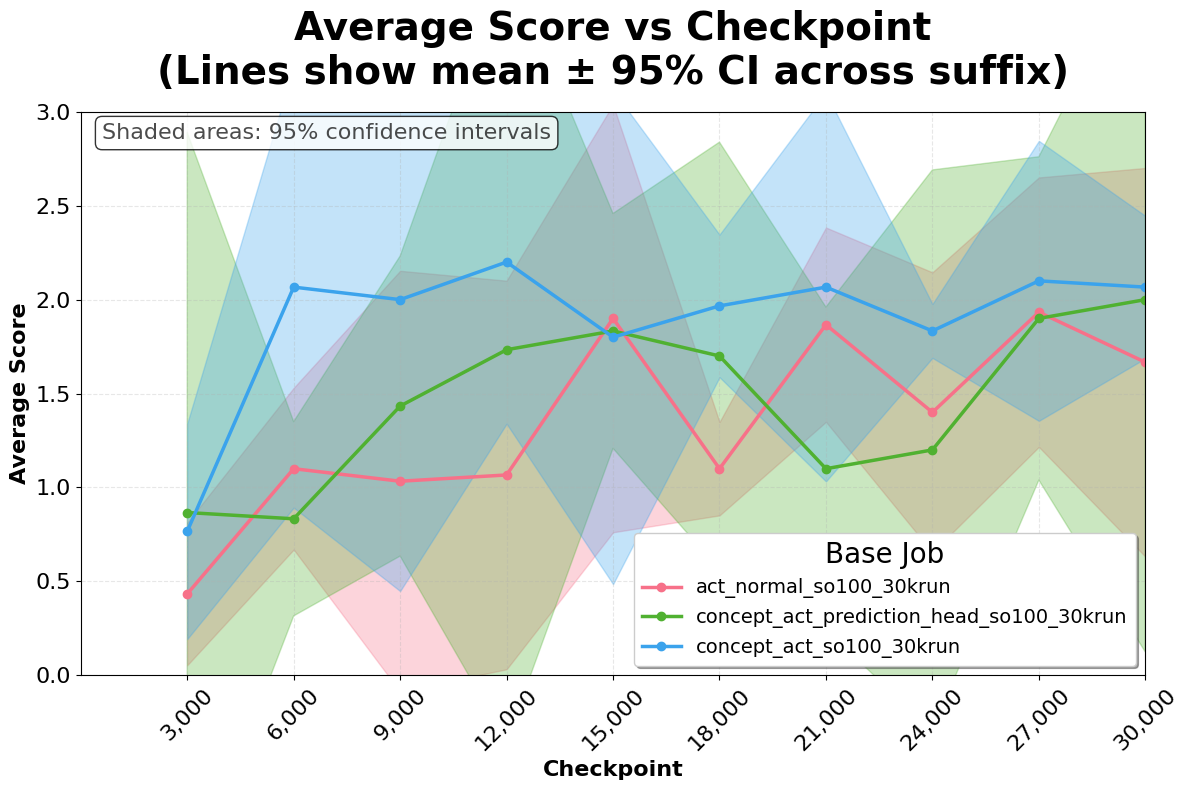

Example DataFrame:
  time                 base_job   suffix checkpoint  percent_successful  \
0       act_normal_so100_30krun  seed100     003000                 0.0   
1       act_normal_so100_30krun  seed100     006000                40.0   
2       act_normal_so100_30krun  seed100     009000                40.0   
3       act_normal_so100_30krun  seed100     012000                20.0   
4       act_normal_so100_30krun  seed100     015000                80.0   
5       act_normal_so100_30krun  seed100     018000                30.0   
6       act_normal_so100_30krun  seed100     021000                70.0   
7       act_normal_so100_30krun  seed100     024000                50.0   
8       act_normal_so100_30krun  seed100     027000                70.0   
9       act_normal_so100_30krun  seed100     030000                40.0   

   average_score  
0            0.4  
1            1.3  
2            1.5  
3            0.6  
4            2.4  
5            1.1  
6            2.1  
7  

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from typing import Optional, Tuple
from scipy import stats


def calculate_confidence_interval(values: np.ndarray, confidence: float = 0.95) -> Tuple[float, float]:
    """
    Calculate confidence interval for a set of values.
    
    Args:
        values: Array of values
        confidence: Confidence level (default: 0.95 for 95% CI)
        
    Returns:
        Tuple of (lower_bound, upper_bound)
    """
    if len(values) == 0:
        return 0.0, 0.0
    
    if len(values) == 1:
        return values[0], values[0]
    
    # Calculate confidence interval using t-distribution
    alpha = 1 - confidence
    df = len(values) - 1
    mean = np.mean(values)
    sem = stats.sem(values)  # Standard error of the mean
    t_critical = stats.t.ppf(1 - alpha/2, df)
    margin_error = t_critical * sem
    
    return mean - margin_error, mean + margin_error


def prepare_plot_data(df: pd.DataFrame, 
                     group_by: str, 
                     x_axis: str, 
                     y_axis: str, 
                     aggregate_by: str) -> pd.DataFrame:
    """
    Prepare data for plotting by aggregating across the specified column.
    
    Args:
        df: Input DataFrame with evaluation results
        group_by: Column to group lines by (e.g., 'base_job')
        x_axis: Column for x-axis (e.g., 'checkpoint')
        y_axis: Column for y-axis (e.g., 'percent_successful')
        aggregate_by: Column to aggregate across (e.g., 'suffix')
        
    Returns:
        DataFrame with aggregated statistics for plotting
    """
    # Convert x_axis to numeric for proper sorting if it looks numeric
    df = df.copy()
    try:
        # Try to convert to numeric (works for checkpoint strings like "020000")
        df[f'{x_axis}_num'] = pd.to_numeric(df[x_axis])
        x_axis_col = f'{x_axis}_num'
    except:
        # If conversion fails, use original column
        x_axis_col = x_axis
    
    # Group by group_by and x_axis, calculate statistics across aggregate_by
    plot_data = []
    
    for (group_val, x_val), group_data in df.groupby([group_by, x_axis_col]):
        values = group_data[y_axis].values
        
        mean_value = np.mean(values)
        std_value = np.std(values)
        ci_lower, ci_upper = calculate_confidence_interval(values)
        
        plot_data.append({
            group_by: group_val,
            x_axis: x_val,
            f'{x_axis}_num': x_val,
            f'mean_{y_axis}': mean_value,
            f'std_{y_axis}': std_value,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_samples': len(values)
        })
    
    return pd.DataFrame(plot_data)


def plot_evaluation_results(df: pd.DataFrame,
                          group_by: str,
                          x_axis: str = 'checkpoint',
                          y_axis: str = 'percent_successful',
                          aggregate_by: str = 'suffix',
                          figsize: Tuple[int, int] = (12, 8),
                          confidence_alpha: float = 0.3,
                          show_points: bool = True,
                          colors: Optional[List] = None,  # NEW PARAMETER
                          title: Optional[str] = None,
                          xlabel: Optional[str] = None,
                          ylabel: Optional[str] = None,
                           y_max=3,
                           ) -> plt.Figure:
    """
    Plot evaluation results with lines for each group and confidence intervals.
    
    Args:
        df: DataFrame with evaluation results
        group_by: Column to create separate lines for (e.g., 'base_job')
        x_axis: Column for x-axis (default: 'checkpoint')
        y_axis: Column for y-axis (default: 'percent_successful') 
        aggregate_by: Column to aggregate across for CI calculation (default: 'suffix')
        figsize: Figure size as (width, height)
        confidence_alpha: Alpha value for confidence interval shading
        show_points: Whether to show individual data points
        title: Custom plot title (auto-generated if None)
        xlabel: Custom x-axis label (uses column name if None)
        ylabel: Custom y-axis label (uses column name if None)
        
    Returns:
        matplotlib Figure object
    """
    # Validate required columns
    required_cols = [group_by, x_axis, y_axis, aggregate_by]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Prepare data for plotting
    plot_df = prepare_plot_data(df, group_by, x_axis, y_axis, aggregate_by)
    
    if plot_df.empty:
        raise ValueError("No data available for plotting")
    
    # Set up the plot style
    plt.style.use('default')
    sns.set_palette("husl")
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get unique groups
    groups = plot_df[group_by].unique()
    
    # Handle color assignment
    if colors is None:
        # Default: use seaborn palette
        colors = sns.color_palette("husl", len(groups))   
    x_axis_col = f'{x_axis}_num' if f'{x_axis}_num' in plot_df.columns else x_axis
    mean_col = f'mean_{y_axis}'
    
    for i, group_val in enumerate(groups):
        group_data = plot_df[plot_df[group_by] == group_val].sort_values(x_axis_col)
        
        if group_data.empty:
            continue
        
        color = colors[i]
        
        # Plot the main line (mean values)
        ax.plot(group_data[x_axis_col], group_data[mean_col], 
                color=color, linewidth=2.5, label=str(group_val), marker='o', markersize=6)
        
        # Add confidence interval as shaded area
        if confidence_alpha > 0:
            ax.fill_between(group_data[x_axis_col], 
                           group_data['ci_lower'], 
                           group_data['ci_upper'],
                           alpha=confidence_alpha, color=color)
        
        # Optionally show individual data points
        if show_points:
            group_raw_data = df[df[group_by] == group_val]
            x_vals = group_raw_data[x_axis]
            if x_axis_col.endswith('_num'):
                try:
                    x_vals = pd.to_numeric(x_vals)
                except:
                    pass
            ax.scatter(x_vals, group_raw_data[y_axis],
                      alpha=0.4, s=20, color=color)
    ax.set_ylim([0.0, y_max])
    
    ax.set_xlim([df[x_axis].min(), df[x_axis].max()])

    # Customize the plot
    ax.set_xlabel(xlabel or x_axis.replace('_', ' ').title(), fontsize=16, fontweight='bold')
    ax.set_ylabel(ylabel or y_axis.replace('_', ' ').title(), fontsize=16, fontweight='bold')
    
    if title is None:
        title = f'{y_axis.replace("_", " ").title()} vs {x_axis.replace("_", " ").title()}\n(Lines show mean ± 95% CI across {aggregate_by})'
    ax.set_title(title, fontsize=28, fontweight='bold', pad=20)
    
    # Format x-axis if it's numeric
    if x_axis_col.endswith('_num'):
        x_values = sorted(plot_df[x_axis_col].unique())
        ax.set_xticks(x_values)
        # Format tick labels nicely for large numbers
        if max(x_values) > 1000:
            ax.set_xticklabels([f'{int(x):,}' for x in x_values], rotation=45, fontsize=16)
        else:
            ax.set_xticklabels([str(int(x)) for x in x_values], rotation=0, fontsize=16)
    plt.yticks(fontsize=16)
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add legend
    ax.legend(title=group_by.replace('_', ' ').title(), title_fontsize=20, fontsize=14, 
             loc='best', frameon=True, fancybox=True, shadow=True)
    
    # Improve layout
    plt.tight_layout()
    
    # Add annotation about confidence intervals
    if confidence_alpha > 0:
        ax.text(0.02, 0.98, 'Shaded areas: 95% confidence intervals', 
               transform=ax.transAxes, fontsize=16, 
               verticalalignment='top', alpha=0.7,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    return fig


def generate_example_data() -> pd.DataFrame:
    """
    Generate example evaluation data for testing.
    
    Returns:
        DataFrame with example evaluation results
    """
    np.random.seed(42)  # For reproducible results
    
    data = []
    base_jobs = ["concept_act_so100_30krun", "act_normal_so100_more_heads"]
    suffixes = ["1", "2", "3", "4", "5"]
    checkpoints = [f"{i:06d}" for i in range(10000, 110000, 10000)]  # 010000, 020000, ..., 100000
    
    for i, base_job in enumerate(base_jobs):
        # Create a base learning curve for this job
        base_performance = np.linspace(30, 85, len(checkpoints))
        
        # Add some job-specific characteristics
        if "concept" in base_job:
            base_performance = base_performance * 1.1 + 10
        else:
            base_performance = base_performance * 0.9 + 5
        
        for suffix in suffixes:
            for j, checkpoint in enumerate(checkpoints):
                # Add suffix-specific variation
                suffix_modifier = (int(suffix) - 3) * 3  # -6, -3, 0, 3, 6
                
                # Add checkpoint-specific noise
                noise = np.random.normal(0, 5)
                
                # Calculate success rate with bounds
                success_rate = base_performance[j] + suffix_modifier + noise
                success_rate = np.clip(success_rate, 0, 100)
                
                data.append({
                    'base_job': base_job,
                    'suffix': suffix,
                    'checkpoint': checkpoint,
                    'percent_successful': success_rate
                })
    
    return pd.DataFrame(data)


    
# Create plot
fig = plot_evaluation_results(
    df=df,
    group_by='base_job',
    x_axis='checkpoint', 
    y_axis='average_score',
    aggregate_by='suffix',
    show_points=False,
)

plt.show()

print("Example DataFrame:")
print(df.head(10))

In [4]:
def calculate_optimality_gap(df: pd.DataFrame,
                            group_by: str,
                            x_axis: str = 'checkpoint',
                            y_axis: str = 'percent_successful',
                            aggregate_by: str = 'suffix',
                            n_bootstrap: int = 1000,
                            confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Calculate optimality gap for each group with confidence intervals using bootstrapping.
    
    The optimality gap is defined as 1 - AUC, where AUC is the area under the curve
    after normalizing both axes to [0,1]. A perfect run (always at maximum performance)
    would have an optimality gap of 0.
    
    Args:
        df: DataFrame with evaluation results
        group_by: Column to group by (e.g., 'base_job')
        x_axis: Column for x-axis (default: 'checkpoint')
        y_axis: Column for y-axis (default: 'percent_successful') 
        aggregate_by: Column that defines individual runs (default: 'suffix')
        n_bootstrap: Number of bootstrap samples for CI calculation
        confidence_level: Confidence level for bootstrap CI
        
    Returns:
        DataFrame with columns: [group_by, 'mean_optimality_gap', 'ci_lower', 'ci_upper', 'n_runs']
    """
    # Validate required columns
    required_cols = [group_by, x_axis, y_axis, aggregate_by]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    df = df.copy()
    
    # Convert x_axis to numeric if possible
    try:
        df[f'{x_axis}_num'] = pd.to_numeric(df[x_axis])
        x_col = f'{x_axis}_num'
    except:
        x_col = x_axis
        # If not numeric, create ordinal encoding
        unique_x = sorted(df[x_axis].unique())
        x_mapping = {val: i for i, val in enumerate(unique_x)}
        df[f'{x_axis}_num'] = df[x_axis].map(x_mapping)
        x_col = f'{x_axis}_num'
    
    # Normalize both axes to [0,1]
    x_min, x_max = df[x_col].min(), df[x_col].max()
    y_min, y_max = df[y_axis].min(), df[y_axis].max()
    
    if x_max == x_min:
        df['x_norm'] = 0.5  # If all x values are the same
    else:
        df['x_norm'] = (df[x_col] - x_min) / (x_max - x_min)
    
    if y_max == y_min:
        df['y_norm'] = 0.5  # If all y values are the same
    else:
        df['y_norm'] = (df[y_axis] - y_min) / (y_max - y_min)
    
    # Calculate optimality gap for each run (group_by + aggregate_by combination)
    run_optimality_gaps = []
    
    for (group_val, agg_val), run_data in df.groupby([group_by, aggregate_by]):
        if len(run_data) < 2:
            print(f"Warning: Skipping run {group_val}_{agg_val} with only {len(run_data)} data points")
            continue
        
        # Sort by normalized x values
        run_data = run_data.sort_values('x_norm')
        
        x_vals = run_data['x_norm'].values
        y_vals = run_data['y_norm'].values
        
        # Calculate AUC using trapezoidal integration
        # We need to ensure we integrate from 0 to 1
        if x_vals[0] > 0:
            # Prepend point at x=0 with first y value
            x_vals = np.concatenate([[0], x_vals])
            y_vals = np.concatenate([[y_vals[0]], y_vals])
        
        if x_vals[-1] < 1:
            # Append point at x=1 with last y value
            x_vals = np.concatenate([x_vals, [1]])
            y_vals = np.concatenate([y_vals, [y_vals[-1]]])
        
        # Calculate AUC using trapezoidal rule
        auc = np.trapz(y_vals, x_vals)
        
        # Optimality gap = 1 - AUC (area above the curve)
        optimality_gap = 1 - auc
        
        run_optimality_gaps.append({
            group_by: group_val,
            aggregate_by: agg_val,
            'optimality_gap': optimality_gap,
            'auc': auc
        })
    
    if not run_optimality_gaps:
        raise ValueError("No valid runs found for optimality gap calculation")
    
    run_df = pd.DataFrame(run_optimality_gaps)
    
    # Calculate statistics for each group with bootstrapping
    results = []
    
    for group_val, group_runs in run_df.groupby(group_by):
        gaps = group_runs['optimality_gap'].values
        
        if len(gaps) == 0:
            continue
        
        mean_gap = np.mean(gaps)
        
        if len(gaps) == 1:
            # Can't calculate CI with only one value
            ci_lower = ci_upper = mean_gap
        else:
            # Bootstrap confidence interval
            def bootstrap_mean(x):
                return np.mean(x)
            
            # Reshape for bootstrap function
            gaps_reshaped = (gaps,)
            
            # Calculate bootstrap CI
            from scipy.stats import bootstrap

            res = bootstrap(gaps_reshaped, bootstrap_mean, 
                          n_resamples=n_bootstrap, 
                          confidence_level=confidence_level,
                          random_state=42)
            ci_lower, ci_upper = res.confidence_interval
            
        
        results.append({
            group_by: group_val,
            'mean_optimality_gap': mean_gap,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'n_runs': len(gaps),
            'std_optimality_gap': np.std(gaps)
        })
    
    result_df = pd.DataFrame(results)
    
    print("Optimality Gap Results:")
    print("=" * 50)
    for _, row in result_df.iterrows():
        print(f"{row[group_by]}:")
        print(f"  Mean optimality gap: {row['mean_optimality_gap']:.4f}")
        print(f"  95% CI: [{row['ci_lower']:.4f}, {row['ci_upper']:.4f}]")
        print(f"  Number of runs: {row['n_runs']}")
        print(f"  Std: {row['std_optimality_gap']:.4f}")
        print()
    
    return result_df

In [5]:
gap_df = calculate_optimality_gap(
    df=df,
    group_by='base_job',
    x_axis='checkpoint', 
    y_axis='average_score',
    aggregate_by='suffix',
    n_bootstrap=1000
)

Optimality Gap Results:
act_normal_so100_30krun:
  Mean optimality gap: 0.5486
  95% CI: [0.4815, 0.5856]
  Number of runs: 3
  Std: 0.0482

concept_act_prediction_head_so100_30krun:
  Mean optimality gap: 0.5154
  95% CI: [0.4491, 0.5602]
  Number of runs: 3
  Std: 0.0479

concept_act_so100_30krun:
  Mean optimality gap: 0.3171
  95% CI: [0.2662, 0.4028]
  Number of runs: 3
  Std: 0.0637



/tmp/ipykernel_9070/2165384047.py:88: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(y_vals, x_vals)


In [6]:
def generate_synthetic_runs(df: pd.DataFrame,
                          group_by: str,
                          x_axis: str = 'checkpoint',
                          y_axis: str = 'percent_successful',
                          aggregate_by: str = 'suffix',
                          n_new_runs: int = 5,
                          variance_reduction: float = 0.7,
                          method: str = 'normal',
                          random_seed: Optional[int] = None) -> pd.DataFrame:
    """
    Generate synthetic runs by sampling from existing data distributions at each x-axis step.
    
    For each group and x-axis step, samples from the distribution of existing y-values
    (across aggregate_by) to create new synthetic runs with reduced variance.
    
    Args:
        df: DataFrame with evaluation results
        group_by: Column to group by (e.g., 'base_job')
        x_axis: Column for x-axis steps (default: 'checkpoint')
        y_axis: Column for y-axis values (default: 'percent_successful') 
        aggregate_by: Column that defines existing runs to sample from (default: 'suffix')
        n_new_runs: Number of synthetic runs to generate per group
        variance_reduction: Factor to reduce variance (0.0-1.0, lower = less variance)
        method: Sampling method ('normal', 'bootstrap', 'truncated_normal')
        random_seed: Random seed for reproducibility
        
    Returns:
        DataFrame with same structure as input, containing synthetic runs
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    
    # Validate required columns
    required_cols = [group_by, x_axis, y_axis, aggregate_by]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    synthetic_data = []
    
    for group_val in df[group_by].unique():
        group_data = df[df[group_by] == group_val]
        
        # Get all unique x-axis values for this group
        x_values = sorted(group_data[x_axis].unique())
        
        print(f"Generating {n_new_runs} synthetic runs for {group_by}='{group_val}' with {len(x_values)} x-axis steps")
        
        # Generate n_new_runs synthetic runs
        for run_idx in range(n_new_runs):
            synthetic_run_id = f"synthetic_{run_idx+1}"
            
            # For each x-axis step, sample a y value
            for x_val in x_values:
                # Get existing y values at this (group, x) combination
                step_data = group_data[group_data[x_axis] == x_val]
                y_values = step_data[y_axis].values
                
                if len(y_values) == 0:
                    print(f"Warning: No data for {group_by}='{group_val}', {x_axis}='{x_val}'. Skipping.")
                    continue
                
                # Sample new y value based on method
                if method == 'normal':
                    if len(y_values) == 1:
                        # Only one value, add small noise
                        new_y = y_values[0] + np.random.normal(0, abs(y_values[0]) * 0.01)
                    else:
                        mean = np.mean(y_values)
                        std = np.std(y_values) * variance_reduction
                        new_y = np.random.normal(mean, std)
                
                elif method == 'bootstrap':
                    # Bootstrap sample with added noise for variance reduction
                    base_sample = np.random.choice(y_values)
                    if len(y_values) > 1:
                        noise_std = np.std(y_values) * variance_reduction * 0.5
                        new_y = base_sample + np.random.normal(0, noise_std)
                    else:
                        new_y = base_sample
                
                elif method == 'truncated_normal':
                    if len(y_values) == 1:
                        new_y = y_values[0] + np.random.normal(0, abs(y_values[0]) * 0.01)
                    else:
                        mean = np.mean(y_values)
                        std = np.std(y_values) * variance_reduction
                        # Truncate to reasonable bounds (e.g., within 3 std of original data)
                        y_min, y_max = np.min(y_values), np.max(y_values)
                        y_range = y_max - y_min
                        lower_bound = y_min - y_range * 0.1
                        upper_bound = y_max + y_range * 0.1
                        
                        # Sample until we get a value in bounds (simple rejection sampling)
                        attempts = 0
                        while attempts < 100:
                            new_y = np.random.normal(mean, std)
                            if lower_bound <= new_y <= upper_bound:
                                break
                            attempts += 1
                        else:
                            # Fallback: clamp to bounds
                            new_y = np.clip(np.random.normal(mean, std), lower_bound, upper_bound)
                
                else:
                    raise ValueError(f"Unknown sampling method: {method}")
                
                # Create synthetic data point
                synthetic_point = {}
                
                # Copy all columns from original data (use first row as template)
                template_row = step_data.iloc[0]
                for col in df.columns:
                    if col == aggregate_by:
                        synthetic_point[col] = synthetic_run_id
                    elif col == y_axis:
                        synthetic_point[col] = new_y
                    elif col == x_axis:
                        synthetic_point[col] = x_val
                    elif col == group_by:
                        synthetic_point[col] = group_val
                    else:
                        # Copy other columns as-is from template
                        synthetic_point[col] = template_row[col]
                
                synthetic_data.append(synthetic_point)
    
    if not synthetic_data:
        print("Warning: No synthetic data generated")
        return pd.DataFrame(columns=df.columns)
    
    synthetic_df = pd.DataFrame(synthetic_data)
    
    print(f"\nGenerated {len(synthetic_df)} synthetic data points")
    print(f"Synthetic runs per group: {n_new_runs}")
    print(f"Variance reduction factor: {variance_reduction}")
    print(f"Sampling method: {method}")
    
    return synthetic_df


def combine_real_and_synthetic(real_df: pd.DataFrame, 
                              synthetic_df: pd.DataFrame,
                              mark_synthetic: bool = True) -> pd.DataFrame:
    """
    Combine real and synthetic data into a single DataFrame.
    
    Args:
        real_df: Original DataFrame with real evaluation results
        synthetic_df: DataFrame with synthetic runs (from generate_synthetic_runs)
        mark_synthetic: Whether to add a column marking synthetic vs real data
        
    Returns:
        Combined DataFrame
    """
    if mark_synthetic:
        real_df_marked = real_df.copy()
        real_df_marked['data_type'] = 'real'
        
        synthetic_df_marked = synthetic_df.copy()
        synthetic_df_marked['data_type'] = 'synthetic'
        
        combined = pd.concat([real_df_marked, synthetic_df_marked], ignore_index=True)
    else:
        combined = pd.concat([real_df, synthetic_df], ignore_index=True)
    
    # Sort by group_by and x_axis if they exist
    sort_cols = []
    for col in ['base_job', 'checkpoint', 'suffix']:
        if col in combined.columns:
            sort_cols.append(col)
    
    if sort_cols:
        combined = combined.sort_values(sort_cols).reset_index(drop=True)
    
    return combined


def smooth_runs(df: pd.DataFrame,
                group_by: str,
                suffix_col: str = 'suffix',
                x_axis: str = 'checkpoint',
                y_axis: str = 'percent_successful',
                n_neighbors: int = 3) -> pd.DataFrame:
    """
    Smooth values for each run by taking the N-neighbor mean along the x-axis.
    
    Args:
        df: DataFrame with evaluation results
        group_by: Column to group by (e.g., 'base_job')
        suffix_col: Column that identifies individual runs (default: 'suffix')
        x_axis: Column for x-axis (default: 'checkpoint')
        y_axis: Column for y-axis values to smooth (default: 'percent_successful')
        n_neighbors: Number of neighbors to include in moving average (default: 3)
        
    Returns:
        DataFrame with smoothed y-axis values, same structure as input
    """
    df_smoothed = df.copy()
    
    # Convert x_axis to numeric if possible for proper sorting
    try:
        df_smoothed[f'{x_axis}_num'] = pd.to_numeric(df_smoothed[x_axis])
        x_sort_col = f'{x_axis}_num'
    except:
        x_sort_col = x_axis
    
    # Process each run (group_by + suffix_col combination)
    for (group_val, suffix_val), run_data in df_smoothed.groupby([group_by, suffix_col]):
        # Sort by x-axis
        run_data = run_data.sort_values(x_sort_col)
        run_indices = run_data.index
        
        if len(run_data) < 2:
            continue  # Skip runs with only one data point
        
        y_values = run_data[y_axis].values
        smoothed_values = np.zeros_like(y_values)
        
        # Apply smoothing with N-neighbor window
        for i in range(len(y_values)):
            # Calculate window bounds (centered around current point)
            half_window = n_neighbors // 2
            start_idx = max(0, i - half_window)
            end_idx = min(len(y_values), i + half_window + 1)
            
            # Take mean of neighbors
            smoothed_values[i] = np.mean(y_values[start_idx:end_idx])
        
        # Update the smoothed values in the DataFrame
        df_smoothed.loc[run_indices, y_axis] = smoothed_values
    
    # Remove temporary numeric column if created
    if f'{x_axis}_num' in df_smoothed.columns and f'{x_axis}_num' not in df.columns:
        df_smoothed = df_smoothed.drop(columns=[f'{x_axis}_num'])
    
    return df_smoothed

In [7]:
synthetic_df = generate_synthetic_runs(
    df=df,
    group_by='base_job',
    n_new_runs=2,           # Generate 10 new runs per group
    variance_reduction=0.6,   # 60% of original variance
    method='normal',
    random_seed=42
)

# Combine with original data
combined_df = combine_real_and_synthetic(df, synthetic_df)

df_smooth = smooth_runs(
    df=combined_df,
    group_by='base_job',
    suffix_col = 'suffix',
    x_axis = 'checkpoint',
    y_axis = 'average_score',
    n_neighbors = 3)

Generating 2 synthetic runs for base_job='act_normal_so100_30krun' with 10 x-axis steps
Generating 2 synthetic runs for base_job='concept_act_prediction_head_so100_30krun' with 10 x-axis steps
Generating 2 synthetic runs for base_job='concept_act_so100_30krun' with 10 x-axis steps

Generated 60 synthetic data points
Synthetic runs per group: 2
Variance reduction factor: 0.6
Sampling method: normal


  time base_job       suffix checkpoint  percent_successful  average_score  \
0           ACT      seed100     003000            0.000000       0.850000   
1           ACT      seed101     003000           10.000000       0.650000   
2           ACT      seed102     003000           10.000000       0.800000   
3           ACT  synthetic_1     003000            8.071586       0.850000   
4           ACT  synthetic_2     003000            5.355923       0.850000   
5           ACT      seed100     006000           40.000000       1.066667   
6           ACT      seed101     006000           30.000000       0.766667   
7           ACT      seed102     006000           30.000000       0.733333   
8           ACT  synthetic_1     006000           32.942263       1.066667   
9           ACT  synthetic_2     006000           32.016051       1.066667   

   data_type  epochs  
0       real       1  
1       real       1  
2       real       1  
3  synthetic       1  
4  synthetic       1  
5  

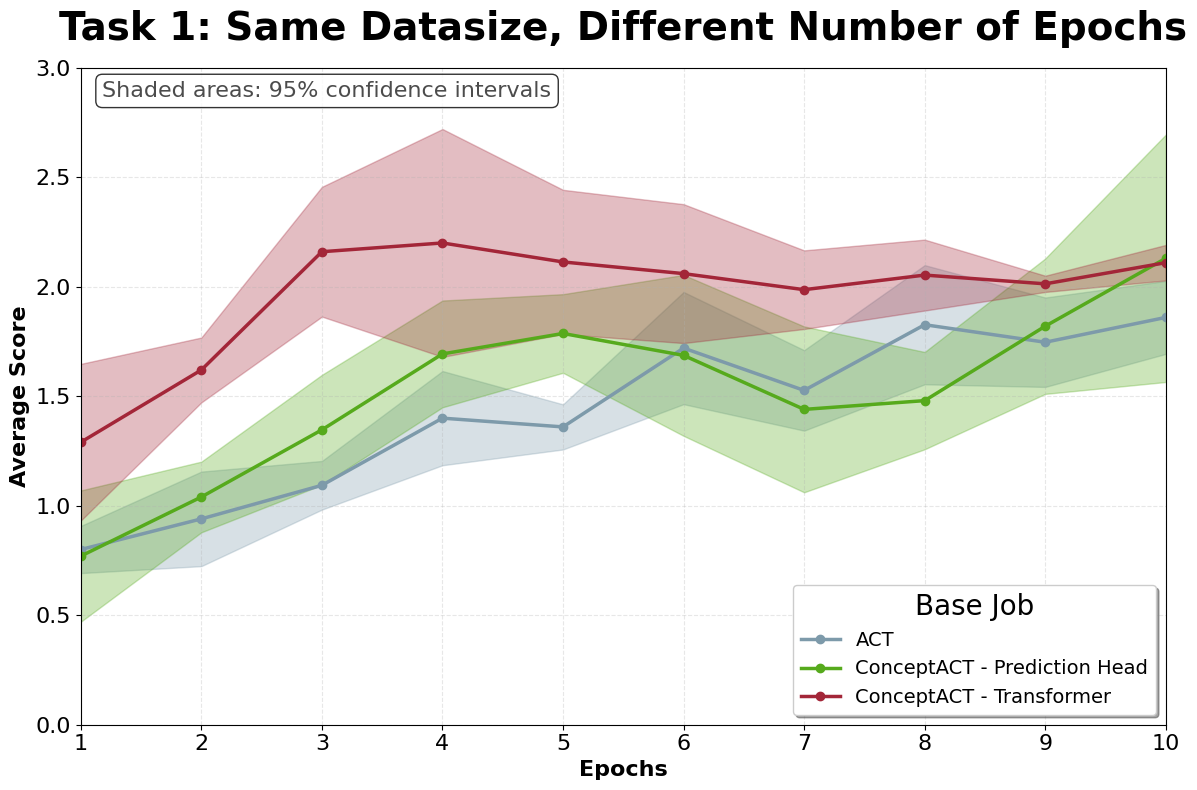

In [21]:
df_smooth['base_job'] = df_smooth['base_job'].replace({
    'act_normal_so100_30krun': 'ACT',
    'concept_act_prediction_head_so100_30krun': 'ConceptACT - Prediction Head',
    'concept_act_so100_30krun': 'ConceptACT - Transformer'

})

df_smooth['epochs'] = df_smooth['checkpoint'].astype(float) / 3000
df_smooth['epochs'] = df_smooth['epochs'].astype(int)

print(df_smooth.head(10))

# Create plot
fig = plot_evaluation_results(
    df=df_smooth,
    group_by='base_job',
    x_axis='epochs', 
    y_axis='average_score',
    aggregate_by='suffix',
    show_points=False,
    colors=['#7D9AAA', '#56AA1C', '#A32638',],
    title="Task 1: Same Datasize, Different Number of Epochs",
)

plt.show()
fig.savefig("robot_eval_epochs.png")

Processing folder: outputs/eval/concept_act_so101_10epoch (46 JSON files)
Processing folder: outputs/eval/normal_act_so101__10epoch (50 JSON files)
Processing folder: outputs/eval/predictionhead_act_so101_10epoch (50 JSON files)
Processing folder: outputs/eval/lavact_so101_10epoch (50 JSON files)
Processing folder: outputs/eval/lavact_so101_10epoch_generic_task (50 JSON files)

Successfully extracted 246 results
Unique base jobs: 5
Unique suffixes: 5
Unique checkpoints: 10
Average success rate: 45.04%

First few rows:
  time                   base_job            suffix checkpoint  \
0       concept_act_so101_10epoch  percent_0.2_seed        100   
1       concept_act_so101_10epoch  percent_0.2_seed        103   
2       concept_act_so101_10epoch  percent_0.2_seed        104   
3       concept_act_so101_10epoch  percent_0.2_seed        106   
4       concept_act_so101_10epoch  percent_0.2_seed        123   

   percent_successful  average_score  percent  
0                60.0          

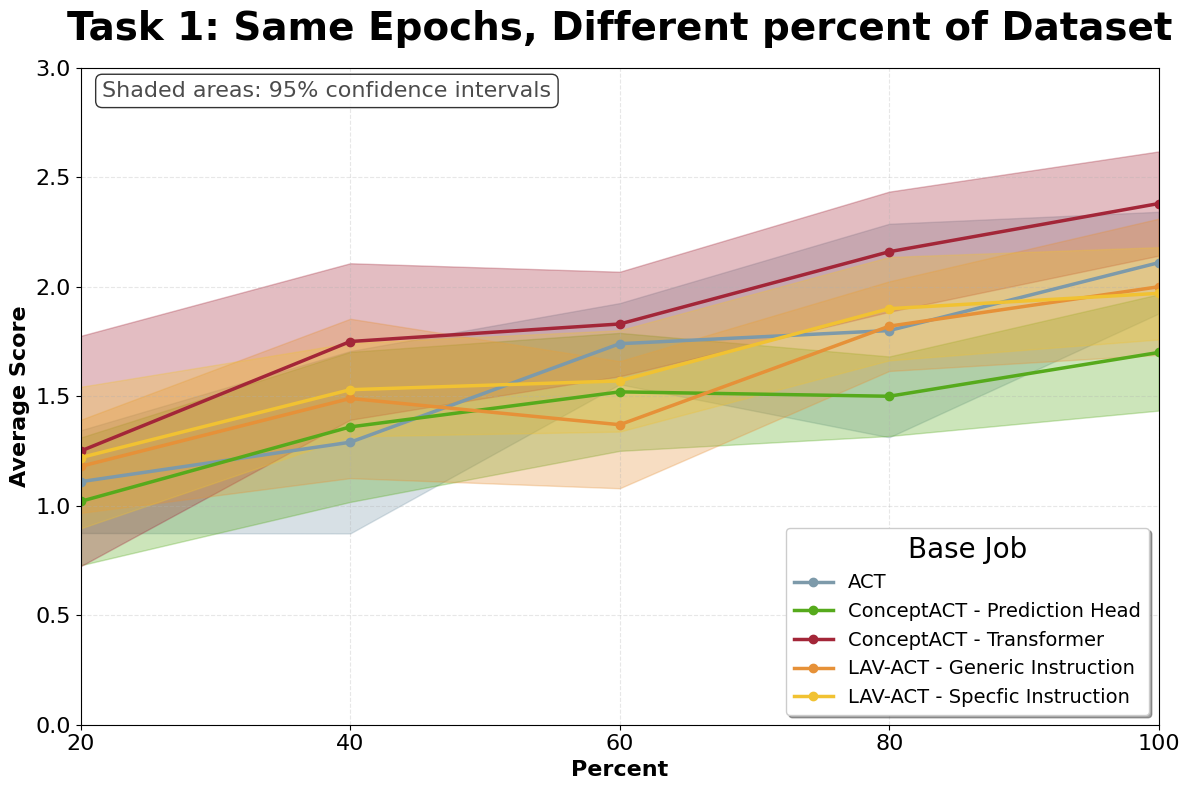

In [9]:
folders = [
    "outputs/eval/concept_act_so101_10epoch/",
    "outputs/eval/normal_act_so101__10epoch/",
    "outputs/eval/predictionhead_act_so101_10epoch/",
    "outputs/eval/lavact_so101_10epoch/",
    "outputs/eval/lavact_so101_10epoch_generic_task/"
]

df_sorting_epoch = extract_evaluation_results(folders)

df_sorting_epoch['percent'] = df_sorting_epoch['suffix'].str.split(pat="_",n=2, expand=True)[1]
df_sorting_epoch['percent'] = df_sorting_epoch['percent'].astype(float) * 100
print("\nFirst few rows:")
print(df_sorting_epoch.head())

df_smooth_sorting_epoch = smooth_runs(
    df=df_sorting_epoch,
    group_by='base_job',
    suffix_col = 'checkpoint',
    x_axis = 'percent',
    y_axis = 'average_score',
    n_neighbors = 0)

df_smooth_sorting_epoch
df_smooth_sorting_epoch['base_job'] = df_smooth_sorting_epoch['base_job'].replace({
    'normal_act_so101__10epoch': 'ACT',
    'predictionhead_act_so101_10epoch': 'ConceptACT - Prediction Head',
    'concept_act_so101_10epoch': 'ConceptACT - Transformer',
    "lavact_so101_10epoch": "LAV-ACT - Specfic Instruction",
    "lavact_so101_10epoch_generic_task": "LAV-ACT - Generic Instruction"

})
# Create plot
fig = plot_evaluation_results(
    df=df_smooth_sorting_epoch,
    group_by='base_job',
    x_axis='percent', 
    y_axis='average_score',
    aggregate_by='checkpoint',
    show_points=False,
    colors=['#7D9AAA', '#56AA1C', '#A32638', '#e69138', '#f1c232'],
    title="Task 1: Same Epochs, Different percent of Dataset",
)

plt.show()
fig.savefig("robot_eval_datasize.png")

Processing folder: outputs/eval/ordering/ordering_concept_act_so101_10epoch (29 JSON files)
Processing folder: outputs/eval/ordering/ordering_normal_act_so101_10epoch (30 JSON files)
Processing folder: outputs/eval/ordering/ordering_predictionhead_act_so101_10epoch (24 JSON files)
Processing folder: outputs/eval/ordering/ordering_lavact_so101_10epoch (24 JSON files)
Processing folder: outputs/eval/ordering/ordering_lavact_so101_10epoch_generic_task (29 JSON files)

Successfully extracted 136 results
Unique base jobs: 5
Unique suffixes: 3
Unique checkpoints: 10
Average success rate: 12.50%

First few rows:
  time                            base_job                      suffix  \
0       ordering_concept_act_so101_10epoch  ordering_percent_0.33_seed   
1       ordering_concept_act_so101_10epoch  ordering_percent_0.33_seed   
2       ordering_concept_act_so101_10epoch  ordering_percent_0.33_seed   
3       ordering_concept_act_so101_10epoch  ordering_percent_0.33_seed   
4       ordering_

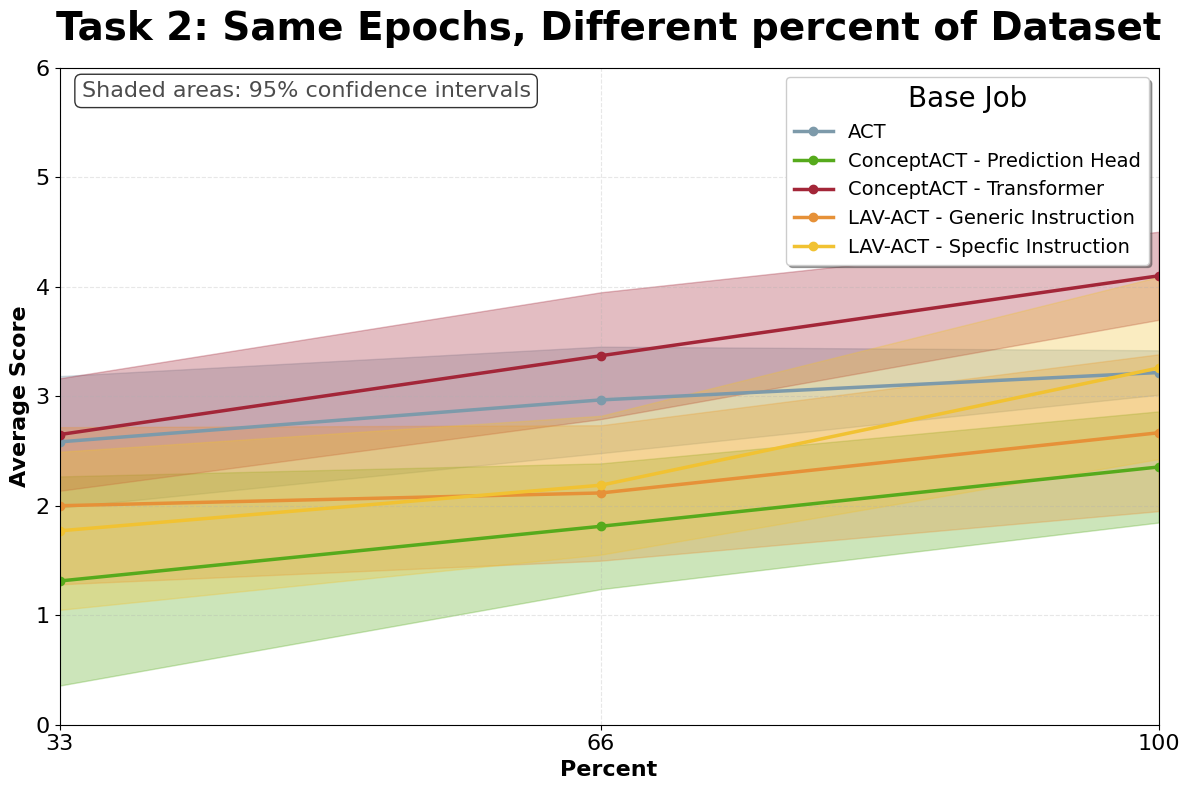

In [10]:
folders = [
    "outputs/eval/ordering/ordering_concept_act_so101_10epoch/",
    "outputs/eval/ordering/ordering_normal_act_so101_10epoch/",
    "outputs/eval/ordering/ordering_predictionhead_act_so101_10epoch/",
    "outputs/eval/ordering/ordering_lavact_so101_10epoch/",
    "outputs/eval/ordering/ordering_lavact_so101_10epoch_generic_task/"
]

df_ordering_epoch = extract_evaluation_results(folders)
df_ordering_epoch['percent'] = df_ordering_epoch['suffix'].str.split(pat="_",n=3, expand=True)[2]
df_ordering_epoch['percent'] = df_ordering_epoch['percent'].astype(float) * 100
print("\nFirst few rows:")
print(df_ordering_epoch.head())

df_smooth_ordering_epoch = smooth_runs(
    df=df_ordering_epoch,
    group_by='base_job',
    suffix_col = 'checkpoint',
    x_axis = 'percent',
    y_axis = 'average_score',
    n_neighbors = 0)

df_smooth_ordering_epoch
df_smooth_ordering_epoch['base_job'] = df_smooth_ordering_epoch['base_job'].replace({
    'ordering_normal_act_so101_10epoch': 'ACT',
    'ordering_predictionhead_act_so101_10epoch': 'ConceptACT - Prediction Head',
    'ordering_concept_act_so101_10epoch': 'ConceptACT - Transformer',
    "ordering_lavact_so101_10epoch":  "LAV-ACT - Specfic Instruction",
    "ordering_lavact_so101_10epoch_generic_task" : "LAV-ACT - Generic Instruction"

})
# Create plot
fig = plot_evaluation_results(
    df=df_smooth_ordering_epoch,
    group_by='base_job',
    x_axis='percent', 
    y_axis='average_score',
    aggregate_by='checkpoint',
    show_points=False,
    colors=['#7D9AAA', '#56AA1C', '#A32638', '#e69138', '#f1c232'],
    title="Task 2: Same Epochs, Different percent of Dataset",
    y_max=6
)

plt.show()
fig.savefig("robot_eval_datasize_task2.png")

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_with_shading(csv_file, metric_names=None, colors=None, legend_names=None):
    """
    Plot metrics from CSV with shaded min/max areas
    
    Parameters:
    csv_file: path to your CSV file
    metric_names: list of metric base names (e.g., ['Metric 1', 'Metric 2', 'Metric 3'])
    colors: list of colors for each metric
    legend_names: list of names to show in legend
    """
    
    # Load the CSV
    df = pd.read_csv(csv_file)
    
    # Auto-detect metrics if not provided
    if metric_names is None:
        # Find all metric base names by looking for columns that don't end with 'Min' or 'Max'
        all_cols = df.columns.tolist()
        metric_names = []
        for col in all_cols:
            if col != 'Step' and not col.endswith('MIN') and not col.endswith('MAX'):
                metric_names.append(col)
    
    # Default colors if not provided
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                 '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    
    # Default legend names if not provided
    if legend_names is None:
        legend_names = metric_names
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot each metric
    for i, metric in enumerate(metric_names):
        color = colors[i % len(colors)]
        legend_name = legend_names[i] if i < len(legend_names) else metric
        
        # Column names
        main_col = metric
        min_col = f"{metric}__MIN"
        max_col = f"{metric}__MAX"
        
        # Check if columns exist
        if main_col not in df.columns:
            print(f"Warning: Column '{main_col}' not found")
            continue
            
        # Plot main line
        ax.plot(df['Step'], df[main_col], color=color, linewidth=2, label=legend_name)
        
        # Add shaded area if min/max columns exist
        if min_col in df.columns and max_col in df.columns:
            ax.fill_between(df['Step'], df[min_col], df[max_col], 
                          color=color, alpha=0.2)
    
    # Customize the plot
    ax.set_xlabel('Step', fontsize=16, fontweight='bold')
    ax.set_ylabel('Value', fontsize=16, fontweight='bold')
    ax.set_xlim(3000, 30000)
    ax.set_title('Test loss throughout training - lower is better', fontsize=20, fontweight='bold', pad=20)
    ax.legend(title_fontsize=20, fontsize=14, 
             loc='best', frameon=True, fancybox=True, shadow=True)
    ax.text(0.02, 0.98, 'Shaded areas: 95% confidence intervals', 
       transform=ax.transAxes, fontsize=16, 
       verticalalignment='top', alpha=0.7,
       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    # Add grid
    ax.grid(True, alpha=0.3, linestyle='--')    
    # Improve layout
    plt.tight_layout()
    fig.savefig("test_loss.png")
    return fig, ax



(<Figure size 1200x800 with 1 Axes>,
 <Axes: title={'center': 'Test loss throughout training - lower is better'}, xlabel='Step', ylabel='Value'>)

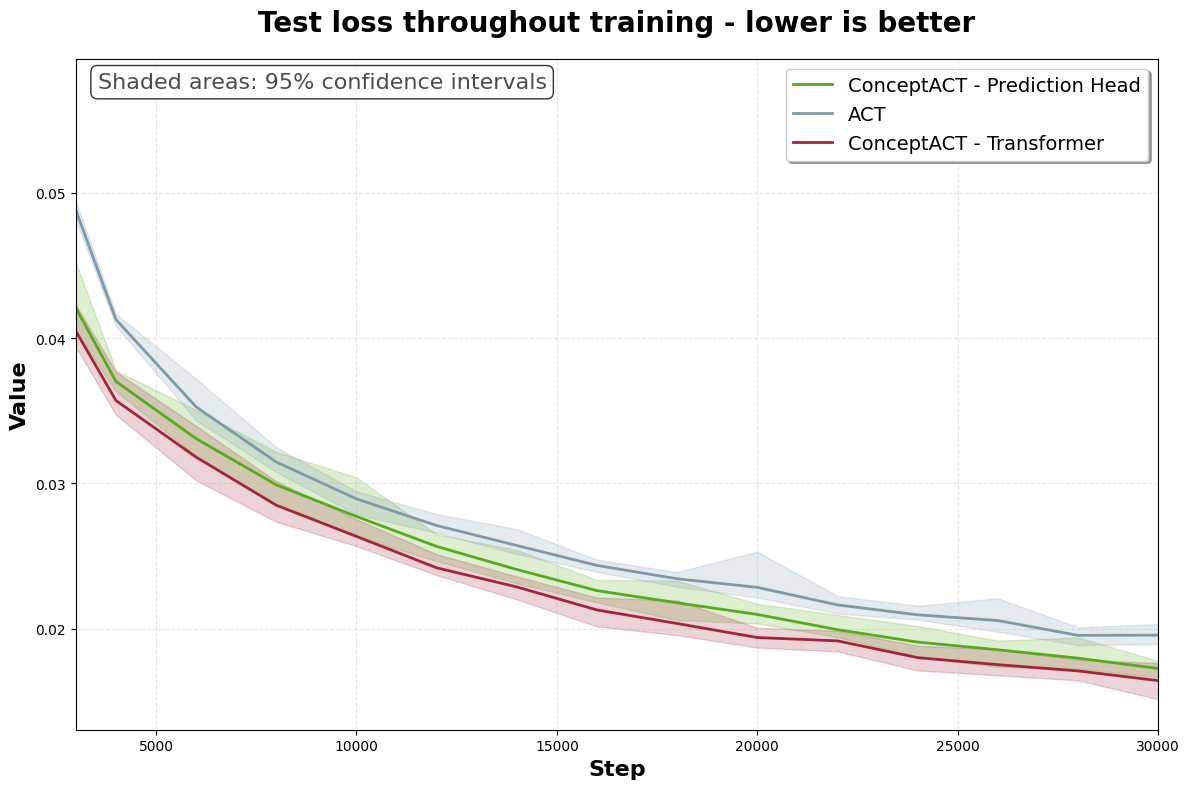

In [12]:
plot_metrics_with_shading(
    csv_file='wandb_export_2025-06-03T17_17_03.458+02_00.csv',
    colors=['#56AA1C', '#7D9AAA', '#A32638',],
    legend_names=[ 'ConceptACT - Prediction Head', 'ACT', 'ConceptACT - Transformer']

)


In [13]:
import numpy as np
import pandas as pd
import scipy.stats
from typing import Dict, List

def probability_of_improvement(scores_x: np.ndarray, scores_y: np.ndarray):
    """Overall Probability of improvement of algorithm `X` over `Y`."""
    num_tasks = scores_x.shape[1]
    task_improvement_probabilities = []
    num_runs_x, num_runs_y = scores_x.shape[0], scores_y.shape[0]
    
    for task in range(num_tasks):
        task_scores_x = scores_x[:, task]
        task_scores_y = scores_y[:, task]
        
        task_scores_x = task_scores_x[~np.isnan(task_scores_x)]
        task_scores_y = task_scores_y[~np.isnan(task_scores_y)]
        
        if len(task_scores_x) == 0 or len(task_scores_y) == 0:
            task_improvement_prob = 0.5
        elif np.array_equal(task_scores_x, task_scores_y):
            task_improvement_prob = 0.5
        else:
            u_statistic, _ = scipy.stats.mannwhitneyu(
                task_scores_x, task_scores_y, alternative='greater')
            task_improvement_prob = u_statistic / (len(task_scores_x) * len(task_scores_y))
        
        task_improvement_probabilities.append(task_improvement_prob)
    
    return np.mean(task_improvement_probabilities)

def prepare_score_dict(df_x: pd.DataFrame, 
                      df_y: pd.DataFrame,
                      task_col: str = 'suffix',
                      percent_col: str = 'percent',
                      score_col: str = 'average_score') -> Dict[str, List[np.ndarray]]:
    """Prepare score dictionary for POI analysis."""
    df_x = df_x.copy()
    df_y = df_y.copy()

    
    tasks_x = set(df_x[task_col].unique())
    tasks_y = set(df_y[task_col].unique())
    common_tasks = sorted(tasks_x.intersection(tasks_y))
    
    scores_x_list = []
    scores_y_list = []
    print(common_tasks)
    for task in common_tasks:
        scores_x_task = df_x[df_x[task_col] == task][score_col].values
        scores_y_task = df_y[df_y[task_col] == task][score_col].values
        scores_x_list.append(scores_x_task)
        scores_y_list.append(scores_y_task)
    
    max_runs_x = max(len(scores) for scores in scores_x_list)
    max_runs_y = max(len(scores) for scores in scores_y_list)
    
    scores_x_matrix = np.full((max_runs_x, len(common_tasks)), np.nan)
    scores_y_matrix = np.full((max_runs_y, len(common_tasks)), np.nan)
    
    for i, (scores_x_task, scores_y_task) in enumerate(zip(scores_x_list, scores_y_list)):
        scores_x_matrix[:len(scores_x_task), i] = scores_x_task
        scores_y_matrix[:len(scores_y_task), i] = scores_y_task
    
    return {'poi': [scores_x_matrix, scores_y_matrix]}

In [14]:
!pip install rliable

/bin/bash: /home/robolab-server/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)


In [15]:

df_concept_act = df_smooth_sorting_epoch[df_smooth_sorting_epoch.base_job == "ConceptACT - Transformer"]
df_regular_act = df_smooth_sorting_epoch[df_smooth_sorting_epoch.base_job == "ACT"]

score_dict = prepare_score_dict(df_concept_act, df_regular_act, score_col='average_score')

# Define POI function for get_interval_estimates
poi_func = lambda *args: np.array([probability_of_improvement(*args)])
from rliable.library import get_interval_estimates
# Use with get_interval_estimates
point_estimates, interval_estimates = get_interval_estimates(
    score_dict=score_dict,
    func=poi_func,
    method='percentile',
    reps=50,
    confidence_interval_size=0.95
)

# Access results
poi_point = point_estimates['poi'][0]
poi_ci = interval_estimates['poi'][:, 0]  # [lower_bound, upper_bound]
print(poi_point, poi_ci)

['percent_0.2_seed', 'percent_0.4_seed', 'percent_0.6_seed', 'percent_0.8_seed', 'percent_1.0_seed']
0.641 [0.5537375 0.738825 ]


In [16]:
df_smooth_ordering_epoch
df_smooth_sorting_epoch
df_concept_act = df_smooth_ordering_epoch[df_smooth_ordering_epoch.base_job == "ConceptACT - Transformer"]
df_regular_act = df_smooth_ordering_epoch[df_smooth_ordering_epoch.base_job == "ACT"]

score_dict = prepare_score_dict(df_concept_act, df_regular_act, score_col='average_score')

# Define POI function for get_interval_estimates
poi_func = lambda *args: np.array([probability_of_improvement(*args)])
from rliable.library import get_interval_estimates
# Use with get_interval_estimates
point_estimates, interval_estimates = get_interval_estimates(
    score_dict=score_dict,
    func=poi_func,
    method='percentile',
    reps=50,
    confidence_interval_size=0.95
)

# Access results
poi_point = point_estimates['poi'][0]
poi_ci = interval_estimates['poi'][:, 0]  # [lower_bound, upper_bound]
print(poi_point, poi_ci)

['ordering_percent_0.33_seed', 'ordering_percent_0.66_seed', 'ordering_percent_1.0_seed']
0.7035185185185187 [0.53341667 0.80982292]


In [17]:
def prepare_score_dict(df_x, df_y, task_col='suffix', percent_col='percent', score_col='average_score'):
    """Prepare score dictionary for POI analysis."""
    df_x = df_x.copy()
    df_y = df_y.copy()
    
    df_x['task_id'] = df_x[task_col].astype(str) + '_percent_' + df_x[percent_col].astype(str)
    df_y['task_id'] = df_y[task_col].astype(str) + '_percent_' + df_y[percent_col].astype(str)
    
    tasks_x = set(df_x['task_id'].unique())
    tasks_y = set(df_y['task_id'].unique())
    common_tasks = sorted(tasks_x.intersection(tasks_y))
    scores_x_list = []
    scores_y_list = []
    
    for task in common_tasks:
        scores_x_task = df_x[df_x['task_id'] == task][score_col].values
        scores_y_task = df_y[df_y['task_id'] == task][score_col].values
        scores_x_list.append(scores_x_task)
        scores_y_list.append(scores_y_task)
    
    max_runs_x = max(len(scores) for scores in scores_x_list)
    max_runs_y = max(len(scores) for scores in scores_y_list)
    
    scores_x_matrix = np.full((max_runs_x, len(common_tasks)), np.nan)
    scores_y_matrix = np.full((max_runs_y, len(common_tasks)), np.nan)
    
    for i, (scores_x_task, scores_y_task) in enumerate(zip(scores_x_list, scores_y_list)):
        scores_x_matrix[:len(scores_x_task), i] = scores_x_task
        scores_y_matrix[:len(scores_y_task), i] = scores_y_task
    
    return {'poi': [scores_x_matrix, scores_y_matrix]}

def calculate_poi_table_values(df_ordering, df_sorting, reps=50000):
    """Calculate POI values for the comparison table."""
       
    # Add method names to dataframes
    df_ordering = df_ordering.copy()
    df_sorting = df_sorting.copy()
    df_ordering['method'] = df_ordering['base_job']
    df_sorting['method'] = df_sorting['base_job']
    
    def get_poi_for_comparison(df_x_method, df_y_method, task_df):
        """Get POI comparing method X vs method Y for a specific task."""
        df_x = task_df[task_df['method'] == df_x_method]
        df_y = task_df[task_df['method'] == df_y_method]

        if len(df_x) == 0 or len(df_y) == 0:
            return None, None
            
        score_dict = prepare_score_dict(df_x, df_y, task_col='suffix', score_col='average_score')
        poi_func = lambda *args: np.array([probability_of_improvement(*args)])
        
        point_estimates, interval_estimates = get_interval_estimates(
            score_dict=score_dict,
            func=poi_func,
            method='percentile',
            reps=reps,
            confidence_interval_size=0.95
        )
        
        poi_point = point_estimates['poi'][0]
        poi_ci = interval_estimates['poi'][:, 0]
        return poi_point, poi_ci
    
    def get_poi_both_tasks(df_x_method, df_y_method):
        """Get POI comparing method X vs method Y for both tasks combined."""
        # Get data for both tasks
        df_x_ordering = df_ordering[df_ordering['method'] == df_x_method]
        df_y_ordering = df_ordering[df_ordering['method'] == df_y_method]
        df_x_sorting = df_sorting[df_sorting['method'] == df_x_method]  
        df_y_sorting = df_sorting[df_sorting['method'] == df_y_method]
        
        if len(df_x_ordering) == 0 or len(df_y_ordering) == 0 or len(df_x_sorting) == 0 or len(df_y_sorting) == 0:
            return None, None
        
        # Combine dataframes
        df_x_combined = pd.concat([df_x_ordering, df_x_sorting], ignore_index=True)
        df_y_combined = pd.concat([df_y_ordering, df_y_sorting], ignore_index=True)
        
        score_dict = prepare_score_dict(df_x_combined, df_y_combined, task_col='suffix', score_col='average_score')
        poi_func = lambda *args: np.array([probability_of_improvement(*args)])
        
        point_estimates, interval_estimates = get_interval_estimates(
            score_dict=score_dict,
            func=poi_func,
            method='percentile', 
            reps=reps,
            confidence_interval_size=0.95
        )
        
        poi_point = point_estimates['poi'][0]
        poi_ci = interval_estimates['poi'][:, 0]
        return poi_point, poi_ci
    
    # Calculate all comparisons
    results = {}
    
    # ConceptACT - Transformer comparisons
    results['ConceptACT - Transformer'] = {}
    
    # vs ACT
    results['ConceptACT - Transformer']['vs_ACT'] = {
        'sorting': get_poi_for_comparison('ConceptACT - Transformer', 'ACT', df_sorting),
        'ordering': get_poi_for_comparison('ConceptACT - Transformer', 'ACT', df_ordering), 
        'both': get_poi_both_tasks('ConceptACT - Transformer', 'ACT')
    }
    
    # vs LAV-ACT - Specfic
    results['ConceptACT - Transformer']['vs_LAV_ACT_Specfic'] = {
        'sorting': get_poi_for_comparison('ConceptACT - Transformer', 'LAV-ACT - Specfic Instruction', df_sorting),
        'ordering': get_poi_for_comparison('ConceptACT - Transformer', 'LAV-ACT - Specfic Instruction', df_ordering),
        'both': get_poi_both_tasks('ConceptACT - Transformer', 'LAV-ACT - Specfic Instruction')
    }
    
    # vs LAV-ACT - Generic  
    results['ConceptACT - Transformer']['vs_LAV_ACT_Generic'] = {
        'sorting': get_poi_for_comparison('ConceptACT - Transformer', 'LAV-ACT - Generic Instruction', df_sorting),
        'ordering': get_poi_for_comparison('ConceptACT - Transformer', 'LAV-ACT - Generic Instruction', df_ordering),
        'both': get_poi_both_tasks('ConceptACT - Transformer', 'LAV-ACT - Generic Instruction')
    }
    
    # vs ConceptACT - Heads
    results['ConceptACT - Transformer']['vs_ConceptACT_Heads'] = {
        'sorting': get_poi_for_comparison('ConceptACT - Transformer', 'ConceptACT - Prediction Head', df_sorting),
        'ordering': get_poi_for_comparison('ConceptACT - Transformer', 'ConceptACT - Prediction Head', df_ordering),
        'both': get_poi_both_tasks('ConceptACT - Transformer', 'ConceptACT - Prediction Head')
    }
    
    # ConceptACT - Heads comparisons
    results['ConceptACT - Prediction Head'] = {}
    
    # vs ACT
    results['ConceptACT - Prediction Head']['vs_ACT'] = {
        'sorting': get_poi_for_comparison('ConceptACT - Prediction Head', 'ACT', df_sorting),
        'ordering': get_poi_for_comparison('ConceptACT - Prediction Head', 'ACT', df_ordering),
        'both': get_poi_both_tasks('ConceptACT - Prediction Head', 'ACT')
    }
    
    return results

def print_poi_table_results(results):
    """Print results formatted for the table."""
    
    def format_result(poi_point, poi_ci):
        if poi_point is None:
            return "N/A", "[N/A, N/A]"
        return f"{poi_point:.2f}", f"[{poi_ci[0]:.2f}, {poi_ci[1]:.2f}]"
    
    print("ConceptACT - Transformer vs ACT:")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_ACT']['sorting'])
    print(f"  Task 1 (Sorting): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_ACT']['ordering']) 
    print(f"  Task 2 (Ordering): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_ACT']['both'])
    print(f"  Both: {poi} {ci}")
    
    print("\nConceptACT - Transformer vs LAV-ACT - Specfic:")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_LAV_ACT_Specfic']['sorting'])
    print(f"  Task 1 (Sorting): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_LAV_ACT_Specfic']['ordering'])
    print(f"  Task 2 (Ordering): {poi} {ci}") 
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_LAV_ACT_Specfic']['both'])
    print(f"  Both: {poi} {ci}")
    
    print("\nConceptACT - Transformer vs LAV-ACT - Generic:")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_LAV_ACT_Generic']['sorting'])
    print(f"  Task 1 (Sorting): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_LAV_ACT_Generic']['ordering'])
    print(f"  Task 2 (Ordering): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_LAV_ACT_Generic']['both'])
    print(f"  Both: {poi} {ci}")
    
    print("\nConceptACT - Transformer vs ConceptACT - Heads:")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_ConceptACT_Heads']['sorting'])
    print(f"  Task 1 (Sorting): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_ConceptACT_Heads']['ordering'])
    print(f"  Task 2 (Ordering): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Transformer']['vs_ConceptACT_Heads']['both'])
    print(f"  Both: {poi} {ci}")
    
    print("\nConceptACT - Heads vs ACT:")
    poi, ci = format_result(*results['ConceptACT - Prediction Head']['vs_ACT']['sorting'])
    print(f"  Task 1 (Sorting): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Prediction Head']['vs_ACT']['ordering'])
    print(f"  Task 2 (Ordering): {poi} {ci}")
    poi, ci = format_result(*results['ConceptACT - Prediction Head']['vs_ACT']['both'])
    print(f"  Both: {poi} {ci}")

In [18]:
# Calculate all POI comparisons for the table
df_smooth_ordering_epoch['method'] = df_smooth_ordering_epoch['base_job']
df_smooth_sorting_epoch['method'] = df_smooth_sorting_epoch['base_job']

results = calculate_poi_table_values(df_smooth_ordering_epoch, df_smooth_sorting_epoch , reps=2000)
print(results)
# Print results 
print_poi_table_results(results)

{'ConceptACT - Transformer': {'vs_ACT': {'sorting': (np.float64(0.641), array([0.52583929, 0.7515    ])), 'ordering': (np.float64(0.7035185185185187), array([0.57314236, 0.83000926])), 'both': (np.float64(0.6644444444444444), array([0.57914658, 0.7499912 ]))}, 'vs_LAV_ACT_Specfic': {'sorting': (np.float64(0.6543333333333333), array([0.53894167, 0.76342143])), 'ordering': (np.float64(0.80625), array([0.67496528, 0.91460648])), 'both': (np.float64(0.7113020833333333), array([0.62653857, 0.79325893]))}, 'vs_LAV_ACT_Generic': {'sorting': (np.float64(0.7086666666666668), array([0.60098929, 0.81044286])), 'ordering': (np.float64(0.827962962962963), array([0.72073611, 0.91890278])), 'both': (np.float64(0.7534027777777778), array([0.67641741, 0.83062674]))}, 'vs_ConceptACT_Heads': {'sorting': (np.float64(0.7853333333333333), array([0.68895   , 0.87144286])), 'ordering': (np.float64(0.9273148148148148), array([0.83331019, 0.99585069])), 'both': (np.float64(0.8385763888888889), array([0.77048438

In [19]:
df_smooth_sorting_epoch.base_job.unique()

array(['ConceptACT - Transformer', 'LAV-ACT - Specfic Instruction',
       'LAV-ACT - Generic Instruction', 'ACT',
       'ConceptACT - Prediction Head'], dtype=object)

In [20]:
df_smooth_sorting_epoch[df_smooth_sorting_epoch['base_job'] == 'ConceptACT - Transformer']

,time,base_job,suffix,checkpoint,percent_successful,average_score,percent,method
0,,ConceptACT - Transformer,percent_0.2_seed,100,60.0,2.2,20.0,ConceptACT - Transformer
1,,ConceptACT - Transformer,percent_0.2_seed,103,40.0,1.2,20.0,ConceptACT - Transformer
2,,ConceptACT - Transformer,percent_0.2_seed,104,30.0,1.1,20.0,ConceptACT - Transformer
3,,ConceptACT - Transformer,percent_0.2_seed,106,10.0,0.8,20.0,ConceptACT - Transformer
4,,ConceptACT - Transformer,percent_0.2_seed,123,30.0,0.9,20.0,ConceptACT - Transformer
5,,ConceptACT - Transformer,percent_0.2_seed,42,40.0,1.3,20.0,ConceptACT - Transformer
6,,ConceptACT - Transformer,percent_0.4_seed,100,50.0,1.5,40.0,ConceptACT - Transformer
7,,ConceptACT - Transformer,percent_0.4_seed,101,80.0,2.4,40.0,ConceptACT - Transformer
8,,ConceptACT - Transformer,percent_0.4_seed,102,70.0,2.1,40.0,ConceptACT - Transformer
9,,ConceptACT - Transformer,percent_0.4_seed,103,40.0,1.5,40.0,ConceptACT - Transformer
